In [1]:
import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import scipy.sparse

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload(sim)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/")
import vis as vis

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/')
import cost_correlation_assign
import differential_splicing
import masking_BBFactor as mask 
import scipy.sparse as sp 

# Add the directory to the Python path (not the script itself)
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")

# Now, import everything from the script
import simulate_pipeline_wALBF as F_sim

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

2.3.0+cu121
12.1
2.3.0+cu121
12.1
2.3.0+cu121
12.1
Using device: cuda
2.3.0+cu121
12.1
Using device: cuda
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [2]:
input_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_Object_with_initializations_brain_only_20241018_134852.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/tabula_senis_test_intron_clusters_50_500000_10_20240927_single_cell.gz"

In [3]:
# Convert input concentration prior into the appropriate type
input_conc = F_sim.handle_input_conc_prior("None")

# Handle cell_type_column input
cell_type_column = None

# Extract parameters from arguments
proportion_negative = 0.5
K_use = 2
input_path = input_file
use_global_prior = False
num_inits = 3
num_epochs = 100
lr = 0.1
ATSE_file = ATSE_file
run_NMF = False
waypoints_use = False
brain_only = True 

# Read in the intron cluster file 
print("Reading in obtained intron cluster (ATSE file!)")
intron_clusts = pd.read_csv(ATSE_file, sep="}")
genes = intron_clusts[["gene_id", "gene_name"]].drop_duplicates()
if brain_only:
    print(f"Running model only on brain cells!")
else:
    print(f"Running on all tissues!")

adata = F_sim.load_adata(input_path)
adata.var = pd.merge(adata.var, genes[['gene_id', 'gene_name']], how='left', on='gene_id')

# Set K to number of unique cell types if column specified otherwise user the provided K
K = adata.obs[cell_type_column].nunique() if cell_type_column else K_use

# Preprocess the data
adata_filtered = F_sim.preprocess_adata(adata, cell_type_column, "cell_by_cluster_matrix")


Reading in obtained intron cluster (ATSE file!)
Running model only on brain cells!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
full_y_tensor, full_total_counts_tensor, adata_input = F_sim.simulate_and_prepare(adata_filtered, K, float_type, proportion_negative, cell_type_column)

Cluster_Counts nnz: 17001075
Junction_Counts nnz: 9021097
The number of unique junctions included in the simulation data is: 16506
The number of unique clusters included in the simulation data is: 5502


100%|██████████| 5502/5502 [00:03<00:00, 1594.32it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 16911843
Junction_Counts nnz: 8955930
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 2
The number of cells is: 19942
The number of junctions is: 15894
Number of negative labels (0): 2649
Number of positive labels (1): 2649


100%|██████████| 5298/5298 [00:08<00:00, 622.39it/s]


Assertion passed: 'junction_id_index' matches the index in 'adata_input.var'.
Done simulating PSI!


Processing clusters: 100%|██████████| 5298/5298 [01:52<00:00, 47.17it/s]


Done normalizing junction counts by cluster!
Done simulating junction counts!
True label counts:
 true_label
negative    10533
positive     5361
Name: count, dtype: int64
Sample label counts:
 sample_label
negative    7947
positive    7947
Name: count, dtype: int64
Cluster_Counts nnz: 16720632
Junction_Counts nnz: 14010461
Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:351: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [5]:
output_dir = F_sim.prepare_output_directory(proportion_negative, K_use, use_global_prior, input_conc, num_inits, num_epochs, cell_type_column, waypoints_use)

In [23]:
len(adata_input.var.Cluster.unique())

5298

In [25]:
adata_input.shape

(19942, 15894)

No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
Not using priors on a and b, running simpler non-hierarchical version!
No initialization matrices provided for PSI and PHI, doing random initialization for variational parameters!


Running on device: cuda
use_global_prior: False
Random seeds: [7053]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 7053
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
cuda
Training in progress for 100 epochs!
Epoch 0, Elbo loss: 69581309.77242006
Epoch 5, Elbo loss: 65043759.957525976
Epoch 10, Elbo loss: 61829885.53685145
Epoch 15, Elbo loss: 59441000.33729607
Epoch 20, Elbo loss: 57537861.48251718
Epoch 25, Elbo loss: 56047015.18323636
Epoch 30, Elbo loss: 54881204.81949419
Epoch 35, Elbo loss: 53873830.576992154
Epoch 40, Elbo loss: 53130723.58894646
Epoch 45, Elbo loss: 52384562.89495039
Epoch 50, Elbo loss: 51853846.35227096
Epoch 55, Elbo loss: 51163424.38558471
Epoch 60, Elbo loss: 50586609.98661107
Epoch 65, Elbo loss: 50126996.85614881
Epoch 70, Elbo loss: 49665195.30960277
Epoch 75, Elbo loss: 49337767.55239147
Epoch 80, Elbo loss: 

Elbo loss: 48156454.4442147


Epoch 95, Elbo loss: 48290154.089016795


No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
Not using priors on a and b, running simpler non-hierarchical version!
No initialization matrices provided for PSI and PHI, doing random initialization for variational parameters!


...

Epoch 95, Elbo loss: 43847951.44722994


No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
Not using priors on a and b, running simpler non-hierarchical version!
No initialization matrices provided for PSI and PHI, doing random initialization for variational parameters!


Loss plot automatically saved to ./analysis_20241023_132020_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_100_LearnedConc_Inits_3_NoCellType_Random_72858/random_init_9432_loss_curve.png
Sample from the guide (posterior)
Calculate summary statistics
All initializations complete. Returning results.
------------------------------------------------
------------------------------------------------
Model variable sizes: {'bb_conc': torch.Size([]), 'a': torch.Size([]), 'b': torch.Size([]), 'psi': torch.Size([2, 15894]), 'pi': torch.Size([2]), 'dir_conc': torch.Size([]), 'assign': torch.Size([19942, 2])}
------------------------------------------------
Random seeds: [9117]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 9117
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
cuda
Training in progress for 100 epochs!
Epoch 0, Elbo loss: 68015065

Elbo loss: 49951127.31094758


Epoch 95, Elbo loss: 50053777.80589057
Loss plot automatically saved to ./analysis_20241023_132020_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_100_LearnedConc_Inits_3_NoCellType_Random_72858/random_init_60239_loss_curve.png
Sample from the guide (posterior)
Calculate summary statistics
All initializations complete. Returning results.
------------------------------------------------
------------------------------------------------
Model variable sizes: {'bb_conc': torch.Size([]), 'a': torch.Size([]), 'b': torch.Size([]), 'psi': torch.Size([2, 15894]), 'pi': torch.Size([2]), 'dir_conc': torch.Size([]), 'assign': torch.Size([19942, 2])}
------------------------------------------------


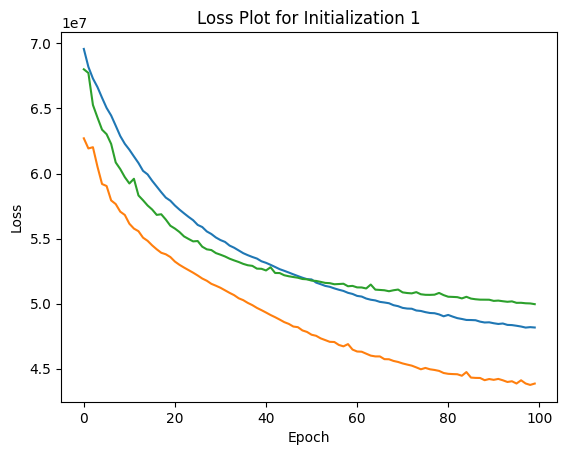

In [6]:
all_results, all_params = F_sim.run_factor_model(adata_input, full_y_tensor, full_total_counts_tensor, K, device, use_global_prior, input_conc, waypoints_use, output_dir, num_inits, num_epochs, lr)

In [7]:
assign_matrices = [result[0]["summary_stats"]["assign"]["mean"] for result in all_results]

# Select the best initialization based on the loss
best_init = np.argmin([result[0]["losses"][-1] for result in all_results])
latent_vars = all_results[best_init][0]['summary_stats']
best_elbo = all_results[best_init][0]["losses"][-1]

# Differential Splicing Analysis
psis_mus = all_params[best_init]["AutoGuideList.0.loc"].reshape(K, latent_vars["psi"]["mean"].shape[1])
psis_loc = all_params[best_init]["AutoGuideList.0.scale"].reshape(K, latent_vars["psi"]["mean"].shape[1])
pi = latent_vars["pi"]["mean"]
assign_post = latent_vars["assign"]["mean"]

In [8]:
assign_post

array([[0.89411545, 0.10588455],
       [0.90261716, 0.09738277],
       [0.0568345 , 0.9431655 ],
       ...,
       [0.86799556, 0.13200447],
       [0.71999615, 0.28000385],
       [0.87292635, 0.12707362]], dtype=float32)

In [9]:
if input_conc == None:
    input_conc = latent_vars["bb_conc"]["mean"]
else:
    input_conc = "infinity"

In [10]:
psis = latent_vars["psi"]["mean"]

# Compute ALBF
albf, l0 = differential_splicing.compute_albf(psis_mus, psis_loc + 1e-9, torch.tensor(pi))
l0 = l0.detach().cpu()
albf = albf.detach().cpu()

# Prepare dataframes
albf_df = pd.DataFrame(albf, columns=["ALBF"])
albf_df["junction_id_index"] = range(albf_df.shape[0])

psis_df = pd.DataFrame(psis.T)
psis_df["junction_id_index"] = psis_df.index
psis_df = psis_df.merge(albf_df, on=["junction_id_index"])

juncs_clusts_labs = adata_input.var[["junction_id_index", "difference", "true_label", "Cluster"]]
psis_df = psis_df.merge(juncs_clusts_labs)

# Convert "true_label" to binary format: 1 for "positive", 0 for "negative"
psis_df['true_label_binary'] = psis_df['true_label'].apply(lambda x: 1 if x == 'positive' else 0)
true_labels = psis_df['true_label_binary']
albf_scores = psis_df['ALBF']

/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/differential_splicing.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pis = torch.tensor(pis, dtype=torch.float32, device=means.device).view(-1, 1)
/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/differential_splicing.py:83: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pis = torch.tensor(pis, dtype=torch.float32, device=means.device).view(-1, 1)  # Ensure correct tensor type and shape


In [11]:
psis_df["delta_est"] = np.abs(psis_df[1] - psis_df[0])
psis_df

,0,1,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est
0,0.262721,0.278664,0,0.014844,0.000000,negative,35178,0,0.015943
1,0.470735,0.458675,1,0.027609,0.000000,negative,35178,0,0.012059
2,0.274825,0.270250,2,0.003324,0.000000,negative,35178,0,0.004575
3,0.505930,0.338465,3,0.562716,0.148104,positive,37286,1,0.167465
4,0.040927,0.364331,4,6.895796,0.296207,positive,37286,1,0.323403
...,...,...,...,...,...,...,...,...,...
15889,0.638910,0.631081,15889,0.009728,0.000000,negative,62094,0,0.007829
15890,0.204582,0.197446,15890,0.003957,0.000000,negative,62094,0,0.007136
15891,0.484773,0.472953,15891,0.001801,0.000000,negative,62095,0,0.011820
15892,0.050905,0.049750,15892,0.002647,0.000000,negative,62095,0,0.001156


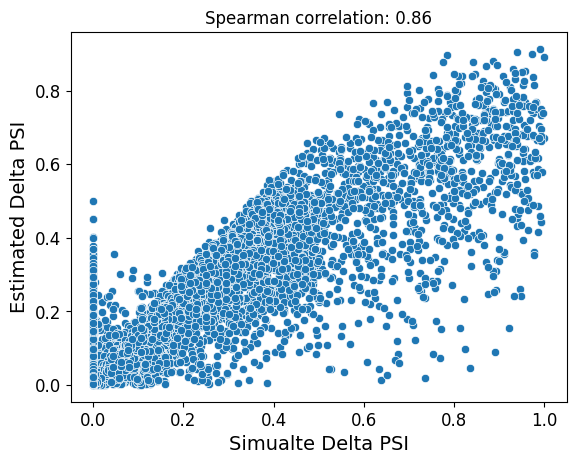

In [19]:
sns.scatterplot(data=psis_df, x="difference", y="delta_est")
correlation_diff = psis_df["delta_est"].corr(psis_df["difference"], method="spearman")
plt.title(f'Spearman correlation: {correlation_diff:.2f}')
plt.xlabel("Simualte Delta PSI", fontsize=14)
plt.ylabel("Estimated Delta PSI", fontsize=14)
# Increase font size for x-axis and y-axis tick labels
plt.tick_params(axis='both', which='major', labelsize=12)